# Notebook 2: Preprocessing & Feature Engineering
## Boris Letić (E2 126/2025) | Bitcoin Sentiment Analysis

**Purpose:** Text preprocessing, feature engineering, rolling windows

**Outputs:**
- Preprocessed tweet features
- Rolling window aggregations
- Train/Val/Test splits

## 1. Setup & NLP Tools

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm
import warnings
import os
import json

warnings.filterwarnings('ignore')
tqdm.pandas()
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Download NLTK data
for resource in ['punkt', 'stopwords', 'wordnet']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

print("✓ Setup complete")

✓ Setup complete


## 2. Load Cleaned Data

In [54]:
tweets = pd.read_csv('data/processed/tweets_cleaned.csv')
prices = pd.read_csv('data/processed/prices_cleaned.csv')
tweets['datetime'] = pd.to_datetime(tweets['datetime'])
prices['datetime'] = pd.to_datetime(prices['datetime'])
print(f"✓ Loaded {len(tweets):,} tweets, {len(prices):,} prices")

✓ Loaded 12,120 tweets, 3,625 prices


## 3. Text Preprocessing

In [55]:
def clean_tweet(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning tweets...")
tweets['text_cleaned'] = tweets['text'].progress_apply(clean_tweet)
tweets = tweets[tweets['text_cleaned'].str.len() > 0].reset_index(drop=True)
print(f"✓ Cleaned {len(tweets):,} tweets")

# Show examples
for i in range(2):
    print(f"\nEx {i+1}:")
    print(f"BEFORE: {tweets['text'].iloc[i][:70]}")
    print(f"AFTER:  {tweets['text_cleaned'].iloc[i][:70]}")

Cleaning tweets...


100%|██████████| 12120/12120 [00:00<00:00, 225897.03it/s]

✓ Cleaned 12,120 tweets

Ex 1:
BEFORE: Interesting Bitcoin discussion on the podcast today 💎
AFTER:  interesting bitcoin discussion on the podcast today

Ex 2:
BEFORE: Bitcoin trading sideways, waiting for a breakout #crypto
AFTER:  bitcoin trading sideways waiting for a breakout crypto


## 4. Tokenization & Lemmatization

In [56]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
crypto_words = {'not', 'no', 'but', 'more', 'down', 'up', 'above', 'below'}
stop_words = stop_words - crypto_words

def tokenize(text):
    if not text: return []
    tokens = word_tokenize(text)
    return [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]

print("Tokenizing...")
tweets['tokens'] = tweets['text_cleaned'].progress_apply(tokenize)
tweets['token_count'] = tweets['tokens'].apply(len)
tweets = tweets[tweets['token_count'] > 0].reset_index(drop=True)

print(f"✓ Tokenized {len(tweets):,} tweets")
print(f"Avg tokens: {tweets['token_count'].mean():.1f}")

Tokenizing...


100%|██████████| 12120/12120 [00:00<00:00, 25241.34it/s]

✓ Tokenized 12,120 tweets
Avg tokens: 5.8


## 5. Sentiment Encoding

In [57]:
sent_map = {'positive': 1.0, 'neutral': 0.0, 'negative': -1.0}
tweets['sentiment_score'] = tweets['sentiment'].map(sent_map)
print("Sentiment encoding:")
for s, v in sent_map.items():
    print(f"  {s}: {v:+.1f}")

Sentiment encoding:
  positive: +1.0
  neutral: +0.0
  negative: -1.0


## 6. Engagement Features

In [58]:
def calc_engagement(row):
    likes = row.get('likes', 0) if pd.notna(row.get('likes', 0)) else 0
    retweets = row.get('retweets', 0) if pd.notna(row.get('retweets', 0)) else 0
    return (likes * 1.0) + (retweets * 2.0)

tweets['engagement_score'] = tweets.apply(calc_engagement, axis=1)
tweets['engagement_log'] = np.log1p(tweets['engagement_score'])
print(f"Engagement: mean={tweets['engagement_score'].mean():.1f}, max={tweets['engagement_score'].max():.0f}")

Engagement: mean=3595.2, max=49000


## 7. Temporal Features

In [59]:
tweets['hour'] = tweets['datetime'].dt.hour
tweets['day_of_week'] = tweets['datetime'].dt.dayofweek
tweets['is_weekend'] = tweets['day_of_week'].isin([5, 6]).astype(int)

def get_period(h):
    if 6 <= h < 12: return 'morning'
    elif 12 <= h < 18: return 'afternoon'
    elif 18 <= h < 24: return 'evening'
    else: return 'night'

tweets['time_period'] = tweets['hour'].apply(get_period)
print("✓ Temporal features created")

✓ Temporal features created


## 8. Hourly Aggregation

In [60]:
hourly = tweets.set_index('datetime').resample('h').agg({
    'sentiment_score': ['mean', 'std', 'min', 'max', 'count'],
    'engagement_score': ['sum', 'mean', 'max'],
    'token_count': 'mean'
})

hourly.columns = ['_'.join(c).strip('_') for c in hourly.columns]
hourly = hourly.reset_index()
hourly = hourly.rename(columns={'sentiment_score_count': 'tweet_volume'})
hourly['tweet_volume'] = hourly['tweet_volume'].fillna(0)
hourly = hourly.ffill().fillna(0)

print(f"✓ Hourly aggregation: {len(hourly):,} hours")

✓ Hourly aggregation: 3,646 hours


## 9. Rolling Window Features (6h, 12h, 24h)

In [61]:
hourly = hourly.sort_values('datetime').reset_index(drop=True)

windows = [6, 12, 24]
for w in windows:
    hourly[f'sentiment_mean_{w}h'] = hourly['sentiment_score_mean'].rolling(w, min_periods=1).mean()
    hourly[f'sentiment_std_{w}h'] = hourly['sentiment_score_std'].rolling(w, min_periods=1).mean()
    hourly[f'tweet_volume_{w}h'] = hourly['tweet_volume'].rolling(w, min_periods=1).sum()
    hourly[f'engagement_{w}h'] = hourly['engagement_score_sum'].rolling(w, min_periods=1).sum()
    hourly[f'sentiment_momentum_{w}h'] = hourly['sentiment_score_mean'].diff(w)

print(f"✓ Rolling windows: {len(windows)} windows × 5 features = {len(windows)*5} features")

✓ Rolling windows: 3 windows × 5 features = 15 features


## 10. Merge with Price Data

In [62]:
merged = prices.set_index('datetime').join(hourly.set_index('datetime'), how='left').reset_index()

# Fill missing
sent_cols = [c for c in merged.columns if 'sentiment' in c or 'tweet' in c or 'engagement' in c]
for c in sent_cols:
    if c in merged.columns:
        merged[c] = merged[c].ffill().fillna(0)

print(f"✓ Merged shape: {merged.shape}")
print(f"Missing values: {merged.isnull().sum().sum()}")

✓ Merged shape: (3625, 31)
Missing values: 1


## 11. Temporal Train/Val/Test Split (60/20/20)

In [63]:
# Sort by time
merged = merged.sort_values('datetime').reset_index(drop=True)

# Calculate split indices
n = len(merged)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

# Split
train = merged.iloc[:train_end].copy()
val = merged.iloc[train_end:val_end].copy()
test = merged.iloc[val_end:].copy()

print("="*60)
print("TEMPORAL SPLIT")
print("="*60)
print(f"Train: {len(train):5,} ({len(train)/n*100:.1f}%) | {train['datetime'].min().date()} to {train['datetime'].max().date()}")
print(f"Val:   {len(val):5,} ({len(val)/n*100:.1f}%) | {val['datetime'].min().date()} to {val['datetime'].max().date()}")
print(f"Test:  {len(test):5,} ({len(test)/n*100:.1f}%) | {test['datetime'].min().date()} to {test['datetime'].max().date()}")
print(f"Total: {n:5,}")
print("="*60)

TEMPORAL SPLIT
Train: 2,175 (60.0%) | 2024-01-01 to 2024-03-31
Val:     725 (20.0%) | 2024-03-31 to 2024-04-30
Test:    725 (20.0%) | 2024-04-30 to 2024-05-31
Total: 3,625


## 12. Export Preprocessed Data

In [64]:
# Save splits
os.makedirs('data/processed', exist_ok=True)

train.to_csv('data/processed/features_train.csv', index=False)
val.to_csv('data/processed/features_val.csv', index=False)
test.to_csv('data/processed/features_test.csv', index=False)

print("✓ Saved: data/processed/features_train.csv")
print("✓ Saved: data/processed/features_val.csv")
print("✓ Saved: data/processed/features_test.csv")

# Save tweet-level data
tweets.to_csv('data/processed/tweets_preprocessed.csv', index=False)
print("✓ Saved: data/processed/tweets_preprocessed.csv")

# Feature summary
summary = {
    'total_tweets': len(tweets),
    'hourly_observations': len(hourly),
    'merged_observations': len(merged),
    'train_size': len(train),
    'val_size': len(val),
    'test_size': len(test),
    'feature_count': len(merged.columns),
    'rolling_windows': windows,
    'feature_names': list(merged.columns)
}

with open('data/processed/feature_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Saved: data/processed/feature_summary.json")

✓ Saved: data/processed/features_train.csv
✓ Saved: data/processed/features_val.csv
✓ Saved: data/processed/features_test.csv
✓ Saved: data/processed/tweets_preprocessed.csv
✓ Saved: data/processed/feature_summary.json


## 13. Feature Distribution Visualizations

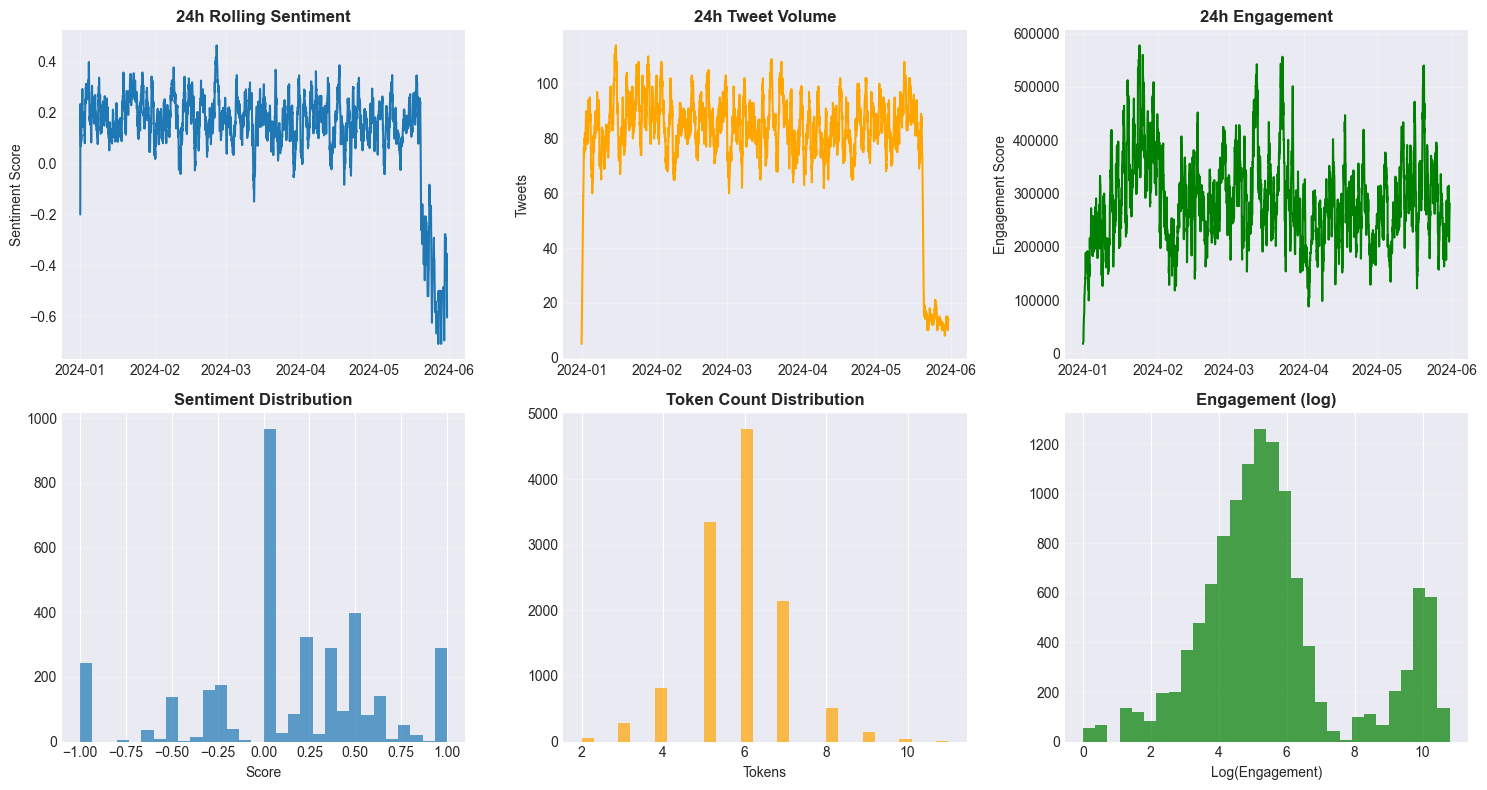

✓ Visualizations complete


In [65]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Rolling sentiment (24h)
axes[0,0].plot(merged['datetime'], merged['sentiment_mean_24h'])
axes[0,0].set_title('24h Rolling Sentiment', fontweight='bold')
axes[0,0].set_ylabel('Sentiment Score')
axes[0,0].grid(True, alpha=0.3)

# Tweet volume (24h)
axes[0,1].plot(merged['datetime'], merged['tweet_volume_24h'], color='orange')
axes[0,1].set_title('24h Tweet Volume', fontweight='bold')
axes[0,1].set_ylabel('Tweets')
axes[0,1].grid(True, alpha=0.3)

# Engagement (24h)
axes[0,2].plot(merged['datetime'], merged['engagement_24h'], color='green')
axes[0,2].set_title('24h Engagement', fontweight='bold')
axes[0,2].set_ylabel('Engagement Score')
axes[0,2].grid(True, alpha=0.3)

# Sentiment distribution
axes[1,0].hist(merged['sentiment_score_mean'].dropna(), bins=30, alpha=0.7)
axes[1,0].set_title('Sentiment Distribution', fontweight='bold')
axes[1,0].set_xlabel('Score')
axes[1,0].grid(True, alpha=0.3, axis='y')

# Token count distribution
axes[1,1].hist(tweets['token_count'], bins=30, alpha=0.7, color='orange')
axes[1,1].set_title('Token Count Distribution', fontweight='bold')
axes[1,1].set_xlabel('Tokens')
axes[1,1].grid(True, alpha=0.3, axis='y')

# Engagement distribution (log)
axes[1,2].hist(tweets['engagement_log'], bins=30, alpha=0.7, color='green')
axes[1,2].set_title('Engagement (log)', fontweight='bold')
axes[1,2].set_xlabel('Log(Engagement)')
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✓ Visualizations complete")